# Default vs Robust Hadamard with ALC (single T = 50 ns)

End-to-end pipeline:
1. Optimize **default** (target-only) and **robust** (σ_z susceptibility) Hadamard pulses in 2-level Hilbert space with $F \geq 0.9999$ hard constraint and smooth controls
2. Re-roll with Piccolo's `unitary_rollout` (cubic-Hermite spline integrator) — verify F
3. ε-sweep with static σ_z perturbation in **2-level** — fidelity curves
4. Cross-check with QuantumToolbox (independent ODE solver)
5. Build ALC drive analytically from $du/dt$ of each pulse, plot $\Omega_\text{main}$ vs $\Omega_\text{main} + \Omega_\text{ALC}$ (Fig 1a style)
6. ε-sweep with static $\hat n$ perturbation in **3-level Duffing** ($\eta = -170$ MHz) — 4 curves: {default, robust} × {with ALC, without ALC}

In [1]:
import Pkg
Pkg.activate(@__DIR__)
piccolo_path       = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop([
    Pkg.PackageSpec(path = piccolo_path),
    Pkg.PackageSpec(path = directtrajopt_path),
])
Pkg.add(["CairoMakie", "MathTeXEngine", "LaTeXStrings", "JLD2",
         "DataInterpolations", "Ipopt", "QuantumToolbox", "Statistics"])
Pkg.instantiate()

using Piccolo
using LinearAlgebra, Random, Printf, Statistics, JLD2
using CairoMakie, MathTeXEngine, LaTeXStrings
using DataInterpolations: CubicHermiteSpline

set_theme!(Theme(
    fonts = (;
        regular = texfont(:text), bold = texfont(:bold),
        italic = texfont(:italic), bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie",
    ),
    Axis = (; xgridvisible = false),
))

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`


## Parameters & operators

In [2]:
# ---- Gate / system parameters ----
const T_NS        = 50.0
const a_bound     = 2π * 0.01            # 10 MHz drive bound
const η_anh       = -2π * 0.170          # -170 MHz anharmonicity (transmon)
const δ_ALC       = η_anh                # ALC tone at |1⟩↔|2⟩, δ_ALC = η (negative)
const F_THRESHOLD = 0.9999
const N_KNOTS     = 50                   # 1 knot per ns at T=50ns
const Δt_GATE     = T_NS / (N_KNOTS - 1) # pin each step so gate = T_NS exactly
const Q_R_DEFAULT = 0.0                  # default: target only
const Q_R_ROBUST  = 100.0                # robust: push robustness hard
const R_DDU       = 10.0                 # smoothness of d²u/dt²
const DDU_BOUND   = 1.0                  # finite to turn on :ddu infrastructure
const NUM_ITER    = 1500
const SEED        = 42

# ---- 2-level operators (Pauli) ----
const σx = ComplexF64[0  1; 1  0]
const σy = ComplexF64[0 -im; im 0]
const σz = ComplexF64[1  0; 0 -1]
const I2 = Matrix{ComplexF64}(I, 2, 2)

# ---- 3-level operators (Duffing) ----
const n_lvl  = 3
const I3     = Matrix{ComplexF64}(I, 3, 3)
const a3     = ComplexF64[0 1 0; 0 0 sqrt(2); 0 0 0]
const ad3    = adjoint(a3)
const X3     = a3 + ad3
const Y3     = im * (ad3 - a3)
const n3     = ad3 * a3                 # diag(0, 1, 2)
const H_anh3 = (η_anh / 2) * n3 * (n3 - I3)
const subspace_indices = [1, 2]

# ---- Hadamard target ----
const U_target = (1/sqrt(2)) * ComplexF64[1.0  1.0; 1.0 -1.0]
const MHz_per_radperns = 1e3 / (2π)

@printf("T = %.1f ns,  η = %.1f MHz,  δ_ALC = %.1f MHz,  N_knots = %d\n",
    T_NS, η_anh/(2π)*1e3, δ_ALC/(2π)*1e3, N_KNOTS)

T = 50.0 ns,  η = -170.0 MHz,  δ_ALC = -170.0 MHz,  N_knots = 50


## Section 1 — Optimize default + robust Hadamard (2-lvl, cubic splines)

In [3]:
function optimize_2lvl(; robust::Bool, seed::Int = SEED)
    Random.seed!(seed)
    drive_bounds = fill(a_bound, 2)
    H_fn      = (u, t) -> u[1] * σx + u[2] * σy
    H_vars_fn = Function[(u, t) -> σz]
    varsys = VariationalQuantumSystem(
        H_fn, H_vars_fn, 2, drive_bounds; time_dependent = true)

    times_knots   = collect(range(0.0, T_NS, length = N_KNOTS))
    controls_init = 0.1 .* a_bound .* randn(2, N_KNOTS)
    pulse         = CubicSplinePulse(controls_init, times_knots)

    Q_r = robust ? Q_R_ROBUST : Q_R_DEFAULT

    qcp = VariationalSplinePulseProblem(
        varsys, pulse, U_target;
        Q              = 0.0,
        Q_r            = Q_r,
        R              = 1e-3,
        R_ddu          = R_DDU,
        du_bound       = Inf,
        ddu_bound      = DDU_BOUND,
        Δt_bounds      = (Δt_GATE, Δt_GATE),  # pin Δt so gate stays at T_NS
        n_path_samples = 3,
    )
    push!(qcp.prob.constraints,
        FinalUnitaryFidelityConstraint(U_target, :Ũ⃗, F_THRESHOLD, get_trajectory(qcp)))

    label = robust ? "ROBUST" : "DEFAULT"
    println("\n--- $label optimization ---")
    t0 = time()
    solve!(qcp; max_iter = NUM_ITER, print_level = 0,
        options = IpoptOptions(
            eval_hessian = false, constr_viol_tol = 1e-8,
            tol = 1e-8, acceptable_tol = 1e-8,
        ))
    @printf("solve wall: %.1f s\n", time() - t0)

    return get_trajectory(qcp)
end

traj_default = optimize_2lvl(; robust = false)
traj_robust  = optimize_2lvl(; robust = true)
println("\nBoth pulses optimized.")

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 1
      added augmented state :var_Ũ⃗  dim=16  (1 error channels)
      dynamics spline order: 3
      added DerivativeIntegrator (:du → :ddu) for acceleration bound
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

--- DEFAULT optimization ---
    initializing optimizer...
      building evaluator: 3 integrators, 2 nonlinear constraints
      dynamics constraints: 1274, nonlinear constraints: 589
        integrator 1 jacobian structure: 0.177s
        integrator 2 jacobian structure: 0.014s
        integrator 3 jacobian structure: 0.025s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.797s
        constraint 2 (NonlinearKnotPointConst

## Section 2 — Verify with `unitary_rollout` (cubic-Hermite spline integrator)

In [4]:
# Build a plain QuantumSystem matching the 2-lvl drive Hamiltonian for honest rollout
const sys_2lvl = QuantumSystem(zeros(ComplexF64, 2, 2), [σx, σy], fill(a_bound, 2))

function honest_F(traj)
    Ũ⃗ = unitary_rollout(traj, sys_2lvl;
        interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
    U_T = iso_vec_to_operator(Ũ⃗[:, end])
    return abs2(tr(U_target' * U_T)) / 4
end

@printf("Default  F (honest rollout) = %.6f\n", honest_F(traj_default))
@printf("Robust   F (honest rollout) = %.6f\n", honest_F(traj_robust))

Default  F (honest rollout) = 0.999978
Robust   F (honest rollout) = 0.999801


## Section 3 — ε-sweep with σ_z perturbation (2-level, no leakage to worry about)

Uses `unitary_rollout` with a perturbed system $H_0 + \varepsilon \sigma_z$ at each ε.

In [5]:
εs = collect(range(-2π*0.010, 2π*0.010, length = 51))   # ±10 MHz in rad/ns

function eps_sweep_2lvl(traj)
    Fs = Float64[]
    for ε in εs
        sys_pert = QuantumSystem(ε * σz, [σx, σy], fill(a_bound, 2))
        Ũ⃗  = unitary_rollout(traj, sys_pert;
            interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
        U_T = iso_vec_to_operator(Ũ⃗[:, end])
        push!(Fs, abs2(tr(U_target' * U_T)) / 4)
    end
    return Fs
end

F_default_2lvl = eps_sweep_2lvl(traj_default)
F_robust_2lvl  = eps_sweep_2lvl(traj_robust)
@printf("default: F(ε=0) = %.6f,  F_min = %.6f\n",
    F_default_2lvl[26], minimum(F_default_2lvl))
@printf("robust:  F(ε=0) = %.6f,  F_min = %.6f\n",
    F_robust_2lvl[26],  minimum(F_robust_2lvl))

default: F(ε=0) = 0.999978,  F_min = 0.000712
robust:  F(ε=0) = 0.999801,  F_min = 0.515345


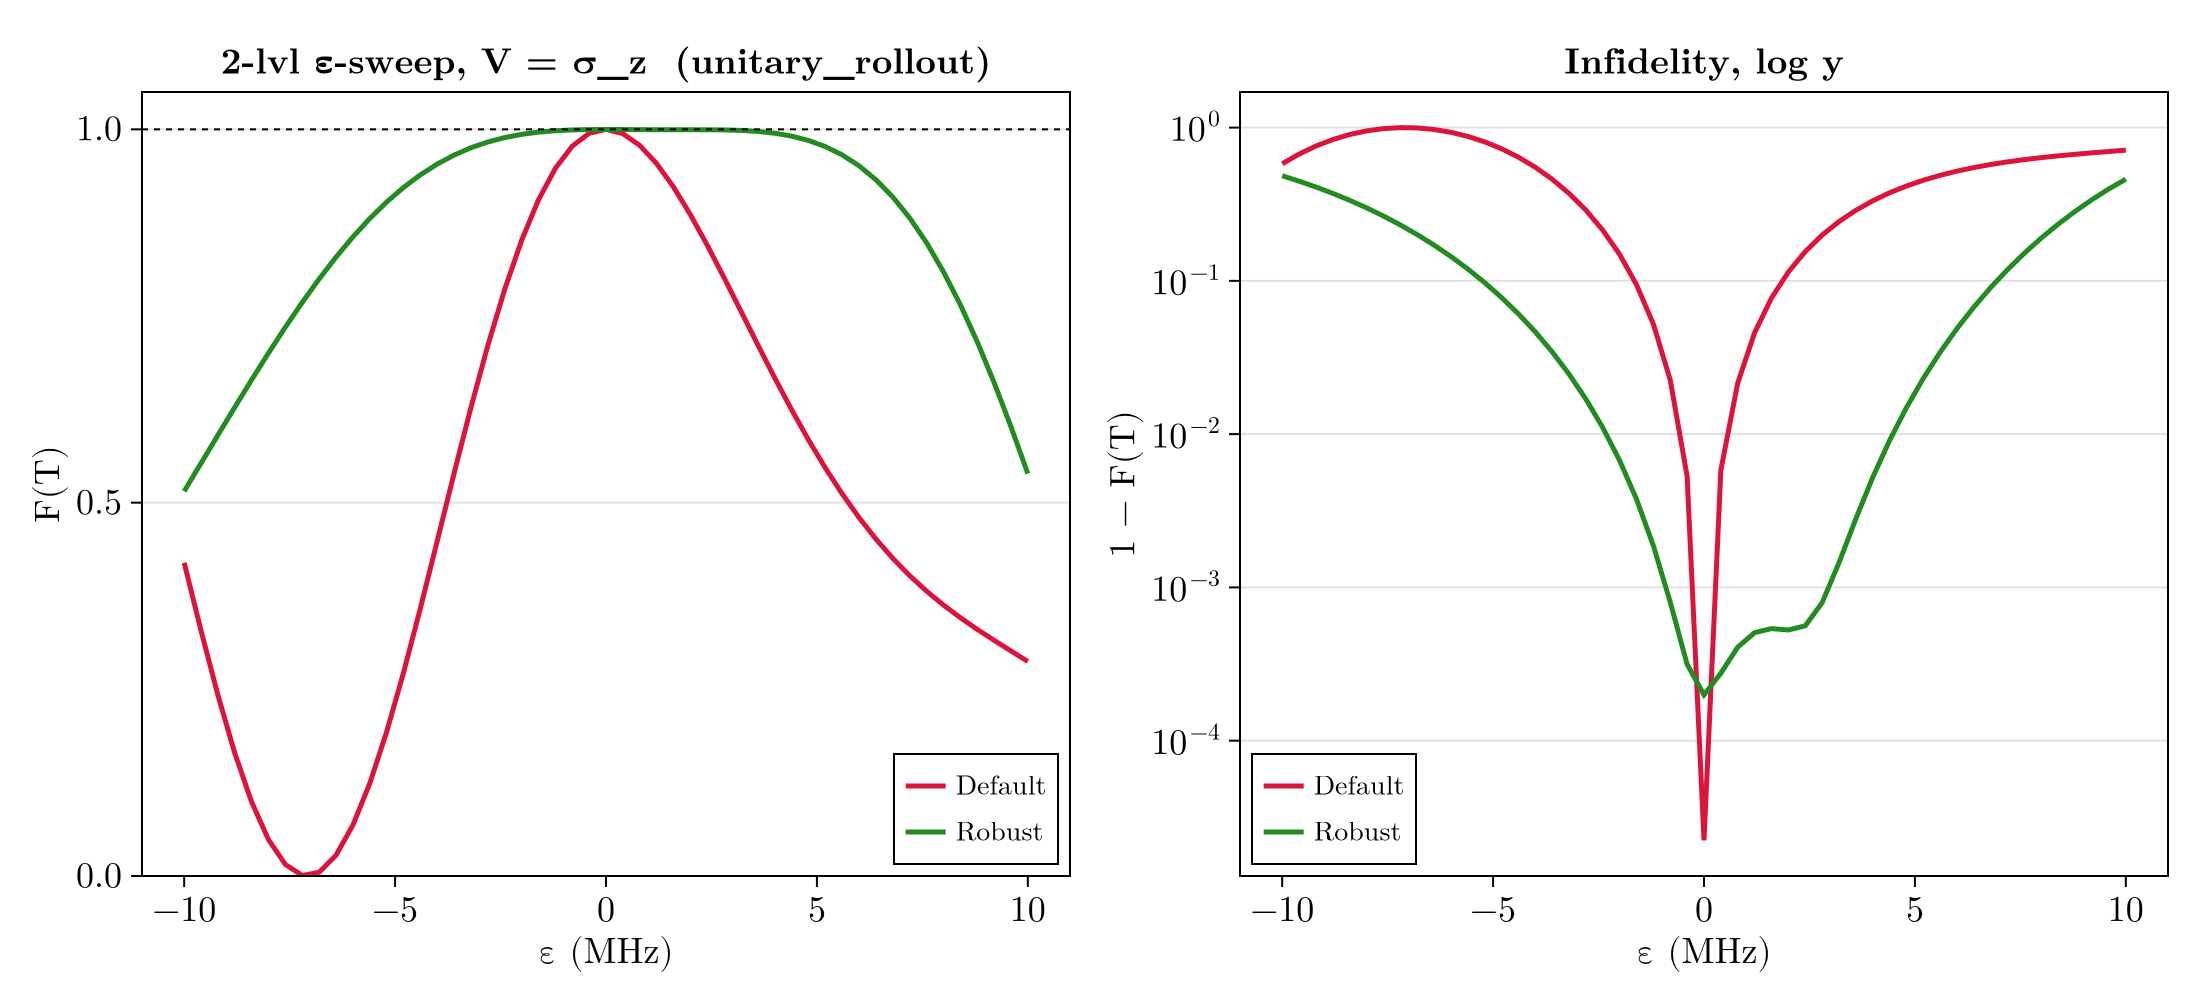

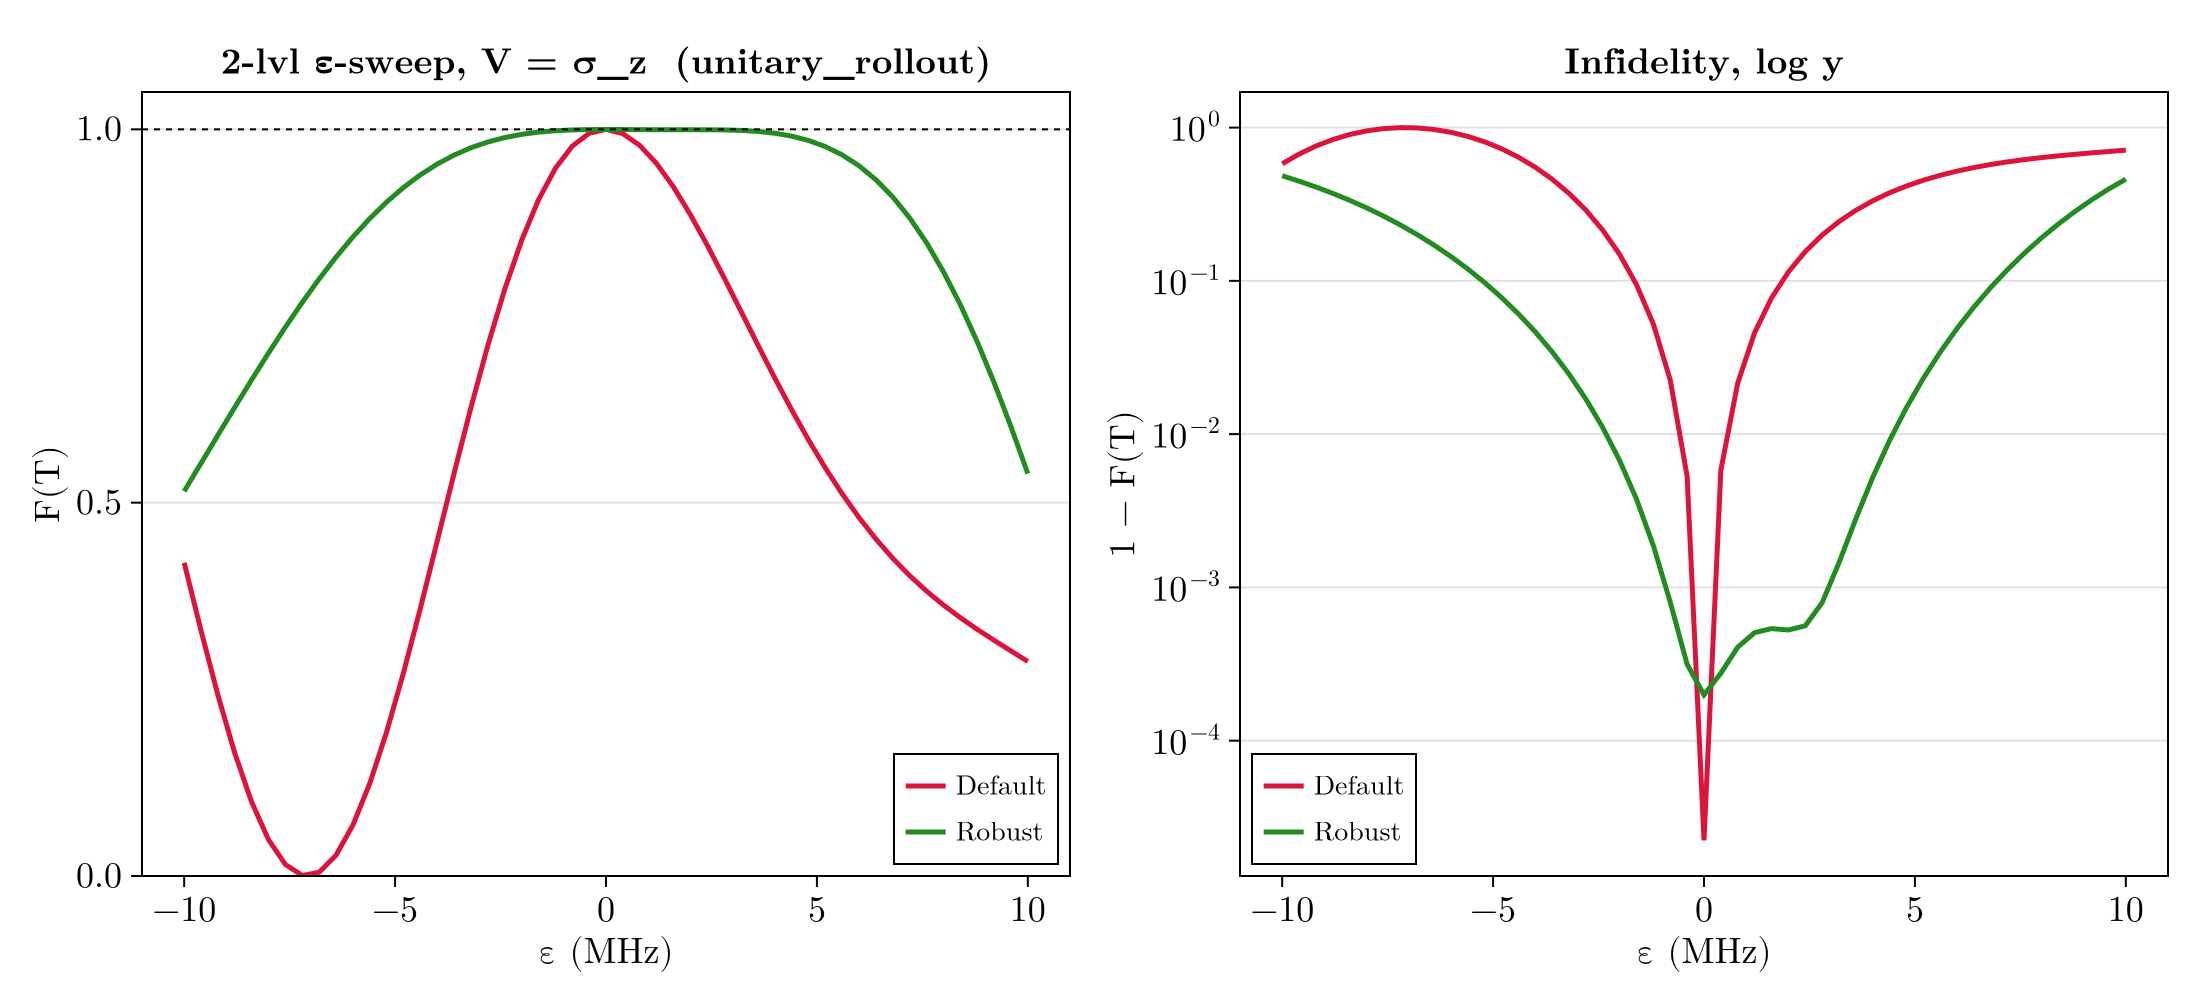

In [6]:
εs_MHz = εs .* MHz_per_radperns

fig = Figure(size = (1100, 500), fontsize = 18)
ax_F   = Axis(fig[1, 1], xlabel = "ε (MHz)", ylabel = "F(T)",
    title = "2-lvl ε-sweep, V = σ_z  (unitary_rollout)")
ax_inf = Axis(fig[1, 2], xlabel = "ε (MHz)", ylabel = "1 − F(T)",
    yscale = log10, title = "Infidelity, log y")

for (lbl, F, c) in [("Default", F_default_2lvl, :crimson),
                    ("Robust",  F_robust_2lvl,  :forestgreen)]
    lines!(ax_F,   εs_MHz, F; color = c, linewidth = 2.5, label = lbl)
    lines!(ax_inf, εs_MHz, max.(1 .- F, 1e-12); color = c, linewidth = 2.5, label = lbl)
end
hlines!(ax_F, [1.0]; color = :black, linestyle = :dash, linewidth = 1)
ylims!(ax_F, 0, 1.05)
axislegend(ax_F;   position = :rb, labelsize = 14)
axislegend(ax_inf; position = :lb, labelsize = 14)
display(fig); fig

## Section 4 — Cross-check with QuantumToolbox (independent ODE solver)

In [7]:
# Build piecewise constant or cubic-spline samples of the optimized controls, then
# propagate via QuantumToolbox's sesolve with adaptive ODE. Cross-validates Piccolo's
# Magnus-based rollout against a completely independent integrator.
using QuantumToolbox
import QuantumToolbox: Qobj, QobjEvo, sesolve, basis

const σx_qt = Qobj(σx)
const σy_qt = Qobj(σy)
const σz_qt = Qobj(σz)

# Build spline functions for u_X(t), u_Y(t) from a trajectory
function spline_callable(traj)
    us  = traj[:u]; dus = traj[:du]
    ts  = collect(range(0.0, T_NS, length = size(us, 2)))
    sp_X = CubicHermiteSpline(dus[1, :], us[1, :], ts)
    sp_Y = CubicHermiteSpline(dus[2, :], us[2, :], ts)
    return t -> (sp_X(t), sp_Y(t))
end

function eps_sweep_qt(traj)
    drive = spline_callable(traj)
    Fs = Float64[]
    for ε in εs
        coef_x = (p, t) -> drive(t)[1]
        coef_y = (p, t) -> drive(t)[2]
        H = QobjEvo((ε * σz_qt, (σx_qt, coef_x), (σy_qt, coef_y)))
        U_T = Matrix{ComplexF64}(I, 2, 2)
        for ψ0_idx in 0:1
            ψ0 = basis(2, ψ0_idx)
            sol = sesolve(H, ψ0, [0.0, T_NS]; progress_bar = Val(false),
                          abstol = 1e-12, reltol = 1e-12)
            ψf  = sol.states[end]
            U_T[:, ψ0_idx + 1] = ψf.data
        end
        push!(Fs, abs2(tr(U_target' * U_T)) / 4)
    end
    return Fs
end

# (QuantumToolbox is heavy — this sweep takes 30-90 s)
println("Running QuantumToolbox ε-sweep (default)...")
@time F_default_qt = eps_sweep_qt(traj_default)
println("Running QuantumToolbox ε-sweep (robust)...")
@time F_robust_qt  = eps_sweep_qt(traj_robust)

# Cross-check stats
println("\n--- Cross-check: unitary_rollout vs QuantumToolbox ---")
@printf("default  max|ΔF| = %.3e\n", maximum(abs.(F_default_2lvl .- F_default_qt)))
@printf("robust   max|ΔF| = %.3e\n", maximum(abs.(F_robust_2lvl  .- F_robust_qt)))

Running QuantumToolbox ε-sweep (default)...
  4.020987 seconds (21.36 M allocations: 1.135 GiB, 18.07% gc time, 90.78% compilation time)
Running QuantumToolbox ε-sweep (robust)...
  0.392550 seconds (13.82 k allocations: 883.875 KiB)

--- Cross-check: unitary_rollout vs QuantumToolbox ---
default  max|ΔF| = 5.603e-10
robust   max|ΔF| = 8.800e-09


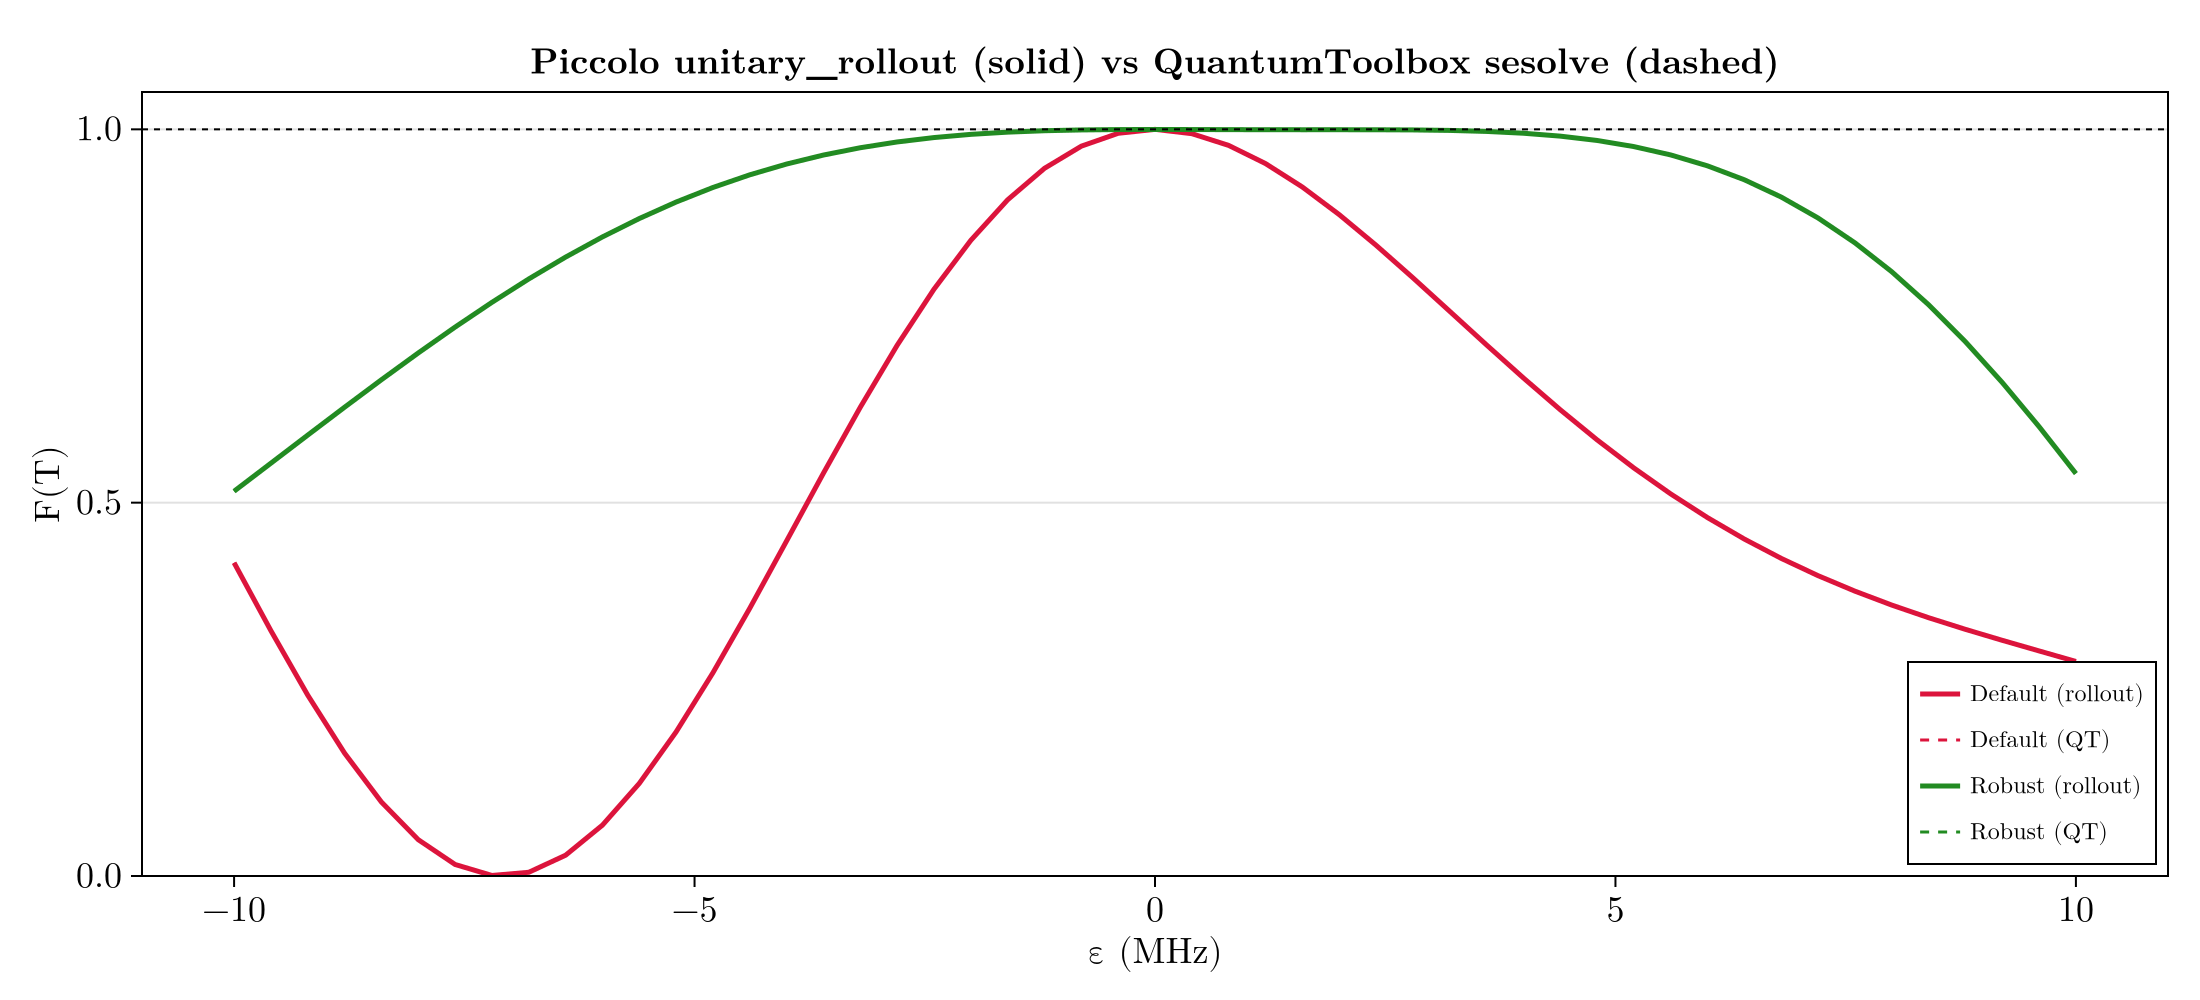

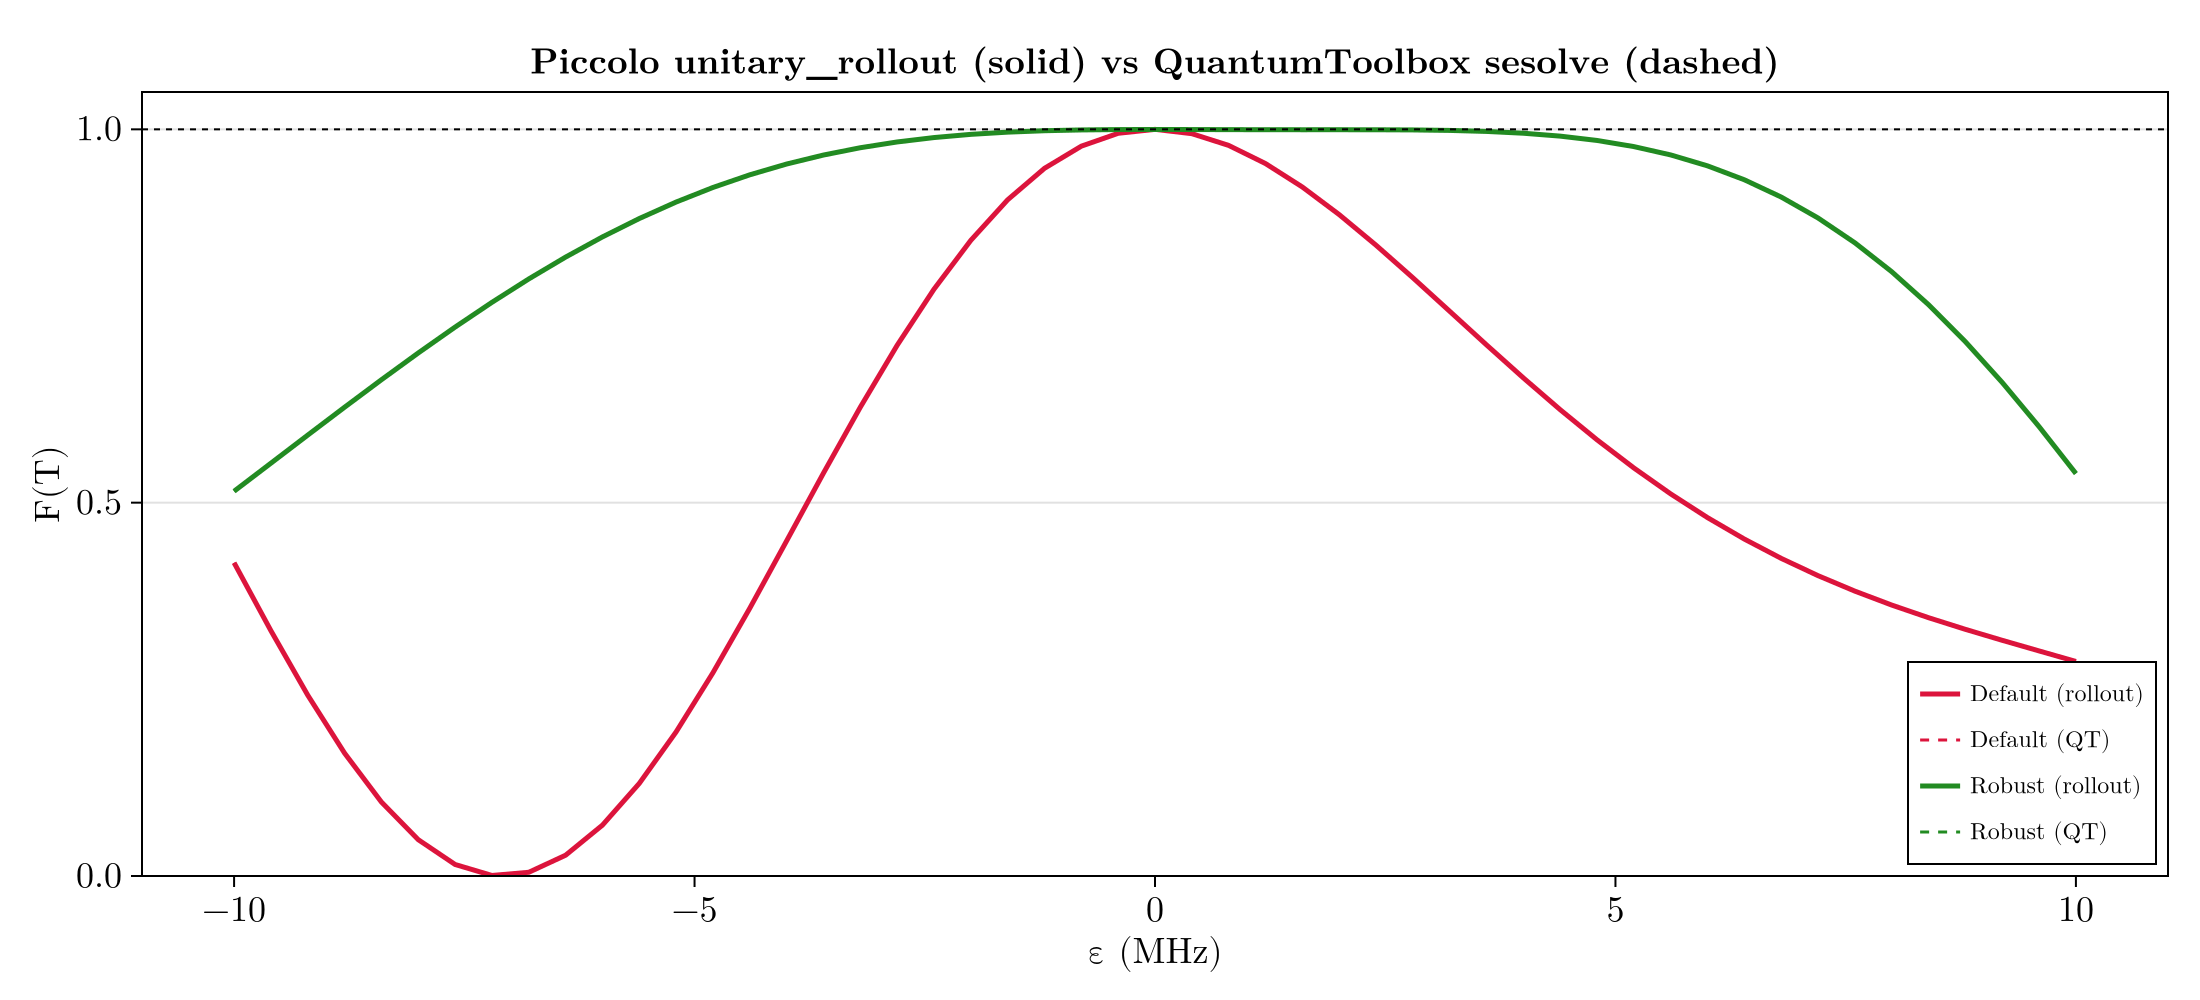

In [8]:
# Plot cross-check
fig = Figure(size = (1100, 500), fontsize = 18)
ax  = Axis(fig[1, 1], xlabel = "ε (MHz)", ylabel = "F(T)",
    title = "Piccolo unitary_rollout (solid) vs QuantumToolbox sesolve (dashed)")

lines!(ax,    εs_MHz, F_default_2lvl; color = :crimson,     linewidth = 2.5, label = "Default (rollout)")
lines!(ax,    εs_MHz, F_default_qt;   color = :crimson,     linewidth = 1.5, linestyle = :dash, label = "Default (QT)")
lines!(ax,    εs_MHz, F_robust_2lvl;  color = :forestgreen, linewidth = 2.5, label = "Robust (rollout)")
lines!(ax,    εs_MHz, F_robust_qt;    color = :forestgreen, linewidth = 1.5, linestyle = :dash, label = "Robust (QT)")
hlines!(ax, [1.0]; color = :black, linestyle = :dash, linewidth = 1)
ylims!(ax, 0, 1.05)
axislegend(ax; position = :rb, labelsize = 12)
display(fig); fig

## Section 5 — Construct ALC drive analytically, plot Ω_main vs Ω_main + Ω_ALC

Per Chiaro-Zhang Eq. 4 (adapted to our angular-frequency convention):

> $\Omega_\text{ALC}(t) = \frac{i\,A_\text{ALC}}{\delta_\text{ALC}} \cdot \frac{d\Omega_\text{main}}{dt} \cdot e^{i \delta_\text{ALC} t}$

We take A_ALC = 1 (no rescaling — pure Chiaro-Zhang formula) and δ_ALC = η_anh.

In [13]:
const ALPHA_DRAG  = 1.0            # DRAG parameter (Chiaro-Zhang: α = 1)
const A_ALC_SCALE = 1.0            # raised-cosine default (per-pulse calibration in Section 5.5)

# Complex-envelope DRAG + ALC, parameterized so we can recalibrate per pulse.
# - DRAG: Ω → Ω + i·(α/η)·dΩ/dt    (puts a zero in Ω̂(η) to first order)
# - ALC:  adds second tone at δ_alc ≈ η with slow envelope ∝ dΩ/dt.  The point
#         is destructive interference with the residual main-pulse leakage at
#         t=T.  Chiaro-Zhang's optimal (A_alc, δ_alc) are derived for a symmetric
#         raised-cosine F(t); for an arbitrary optimized Ω(t) they are *wrong*,
#         and using them adds leakage from the ALC tone instead of cancelling.
#         Section 5.5 calibrates per-pulse.

function build_composite(traj; alpha = ALPHA_DRAG, A_alc = A_ALC_SCALE, δ_alc = δ_ALC)
    us  = traj[:u]; dus = traj[:du]
    ts_knots = collect(range(0.0, T_NS, length = size(us, 2)))
    sp_X = CubicHermiteSpline(dus[1, :], us[1, :], ts_knots)
    sp_Y = CubicHermiteSpline(dus[2, :], us[2, :], ts_knots)

    h = 1e-4
    # Clamped finite difference — degenerates to one-sided at t=0 and t=T_NS
    # so we never query the spline outside [0, T_NS].
    function safe_diff(sp, t)
        t_lo = max(t - h, 0.0)
        t_hi = min(t + h, T_NS)
        return (sp(t_hi) - sp(t_lo)) / (t_hi - t_lo)
    end
    duXdt(t) = safe_diff(sp_X, t)
    duYdt(t) = safe_diff(sp_Y, t)

    κ_drag = alpha / η_anh        # DRAG prefactor (η_anh < 0)
    κ_alc  = A_alc / δ_alc        # ALC prefactor  (δ_alc < 0)

    function pieces(t)
        uX1, uY1 = sp_X(t), sp_Y(t)
        # DRAG-corrected envelope (carrier ω_01)
        uX_drag = uX1 - κ_drag * duYdt(t)
        uY_drag = uY1 + κ_drag * duXdt(t)
        # ALC slow envelope (in the doubly-rotating frame at δ_alc)
        alc_X_env = -κ_alc * duYdt(t)
        alc_Y_env =  κ_alc * duXdt(t)
        # Composite back in the rotating frame at ω_01
        c, s = cos(δ_alc * t), sin(δ_alc * t)
        uX_total = uX_drag + alc_X_env * c - alc_Y_env * s
        uY_total = uY_drag + alc_X_env * s + alc_Y_env * c
        return (uX1, uY1, uX_drag, uY_drag, uX_total, uY_total)
    end
    return pieces
end

# Uncalibrated baseline (raised-cosine defaults).  Replaced by calibration in Section 5.5.
comp_default = build_composite(traj_default)
comp_robust  = build_composite(traj_robust)

ts_fine = collect(range(0.0, T_NS, length = 2000))

data_d   = [comp_default(t) for t in ts_fine]
uX1_d    = [d[1] for d in data_d] .* MHz_per_radperns
uY1_d    = [d[2] for d in data_d] .* MHz_per_radperns
uX_drag_d = [d[3] for d in data_d] .* MHz_per_radperns
uY_drag_d = [d[4] for d in data_d] .* MHz_per_radperns
uX_tot_d  = [d[5] for d in data_d] .* MHz_per_radperns
uY_tot_d  = [d[6] for d in data_d] .* MHz_per_radperns

data_r   = [comp_robust(t) for t in ts_fine]
uX1_r    = [d[1] for d in data_r] .* MHz_per_radperns
uY1_r    = [d[2] for d in data_r] .* MHz_per_radperns
uX_drag_r = [d[3] for d in data_r] .* MHz_per_radperns
uY_drag_r = [d[4] for d in data_r] .* MHz_per_radperns
uX_tot_r  = [d[5] for d in data_r] .* MHz_per_radperns
uY_tot_r  = [d[6] for d in data_r] .* MHz_per_radperns

println("Composite waveforms built — uncalibrated (raised-cosine defaults).")


Composite waveforms built (raw / +DRAG / +DRAG+ALC) for both pulses.


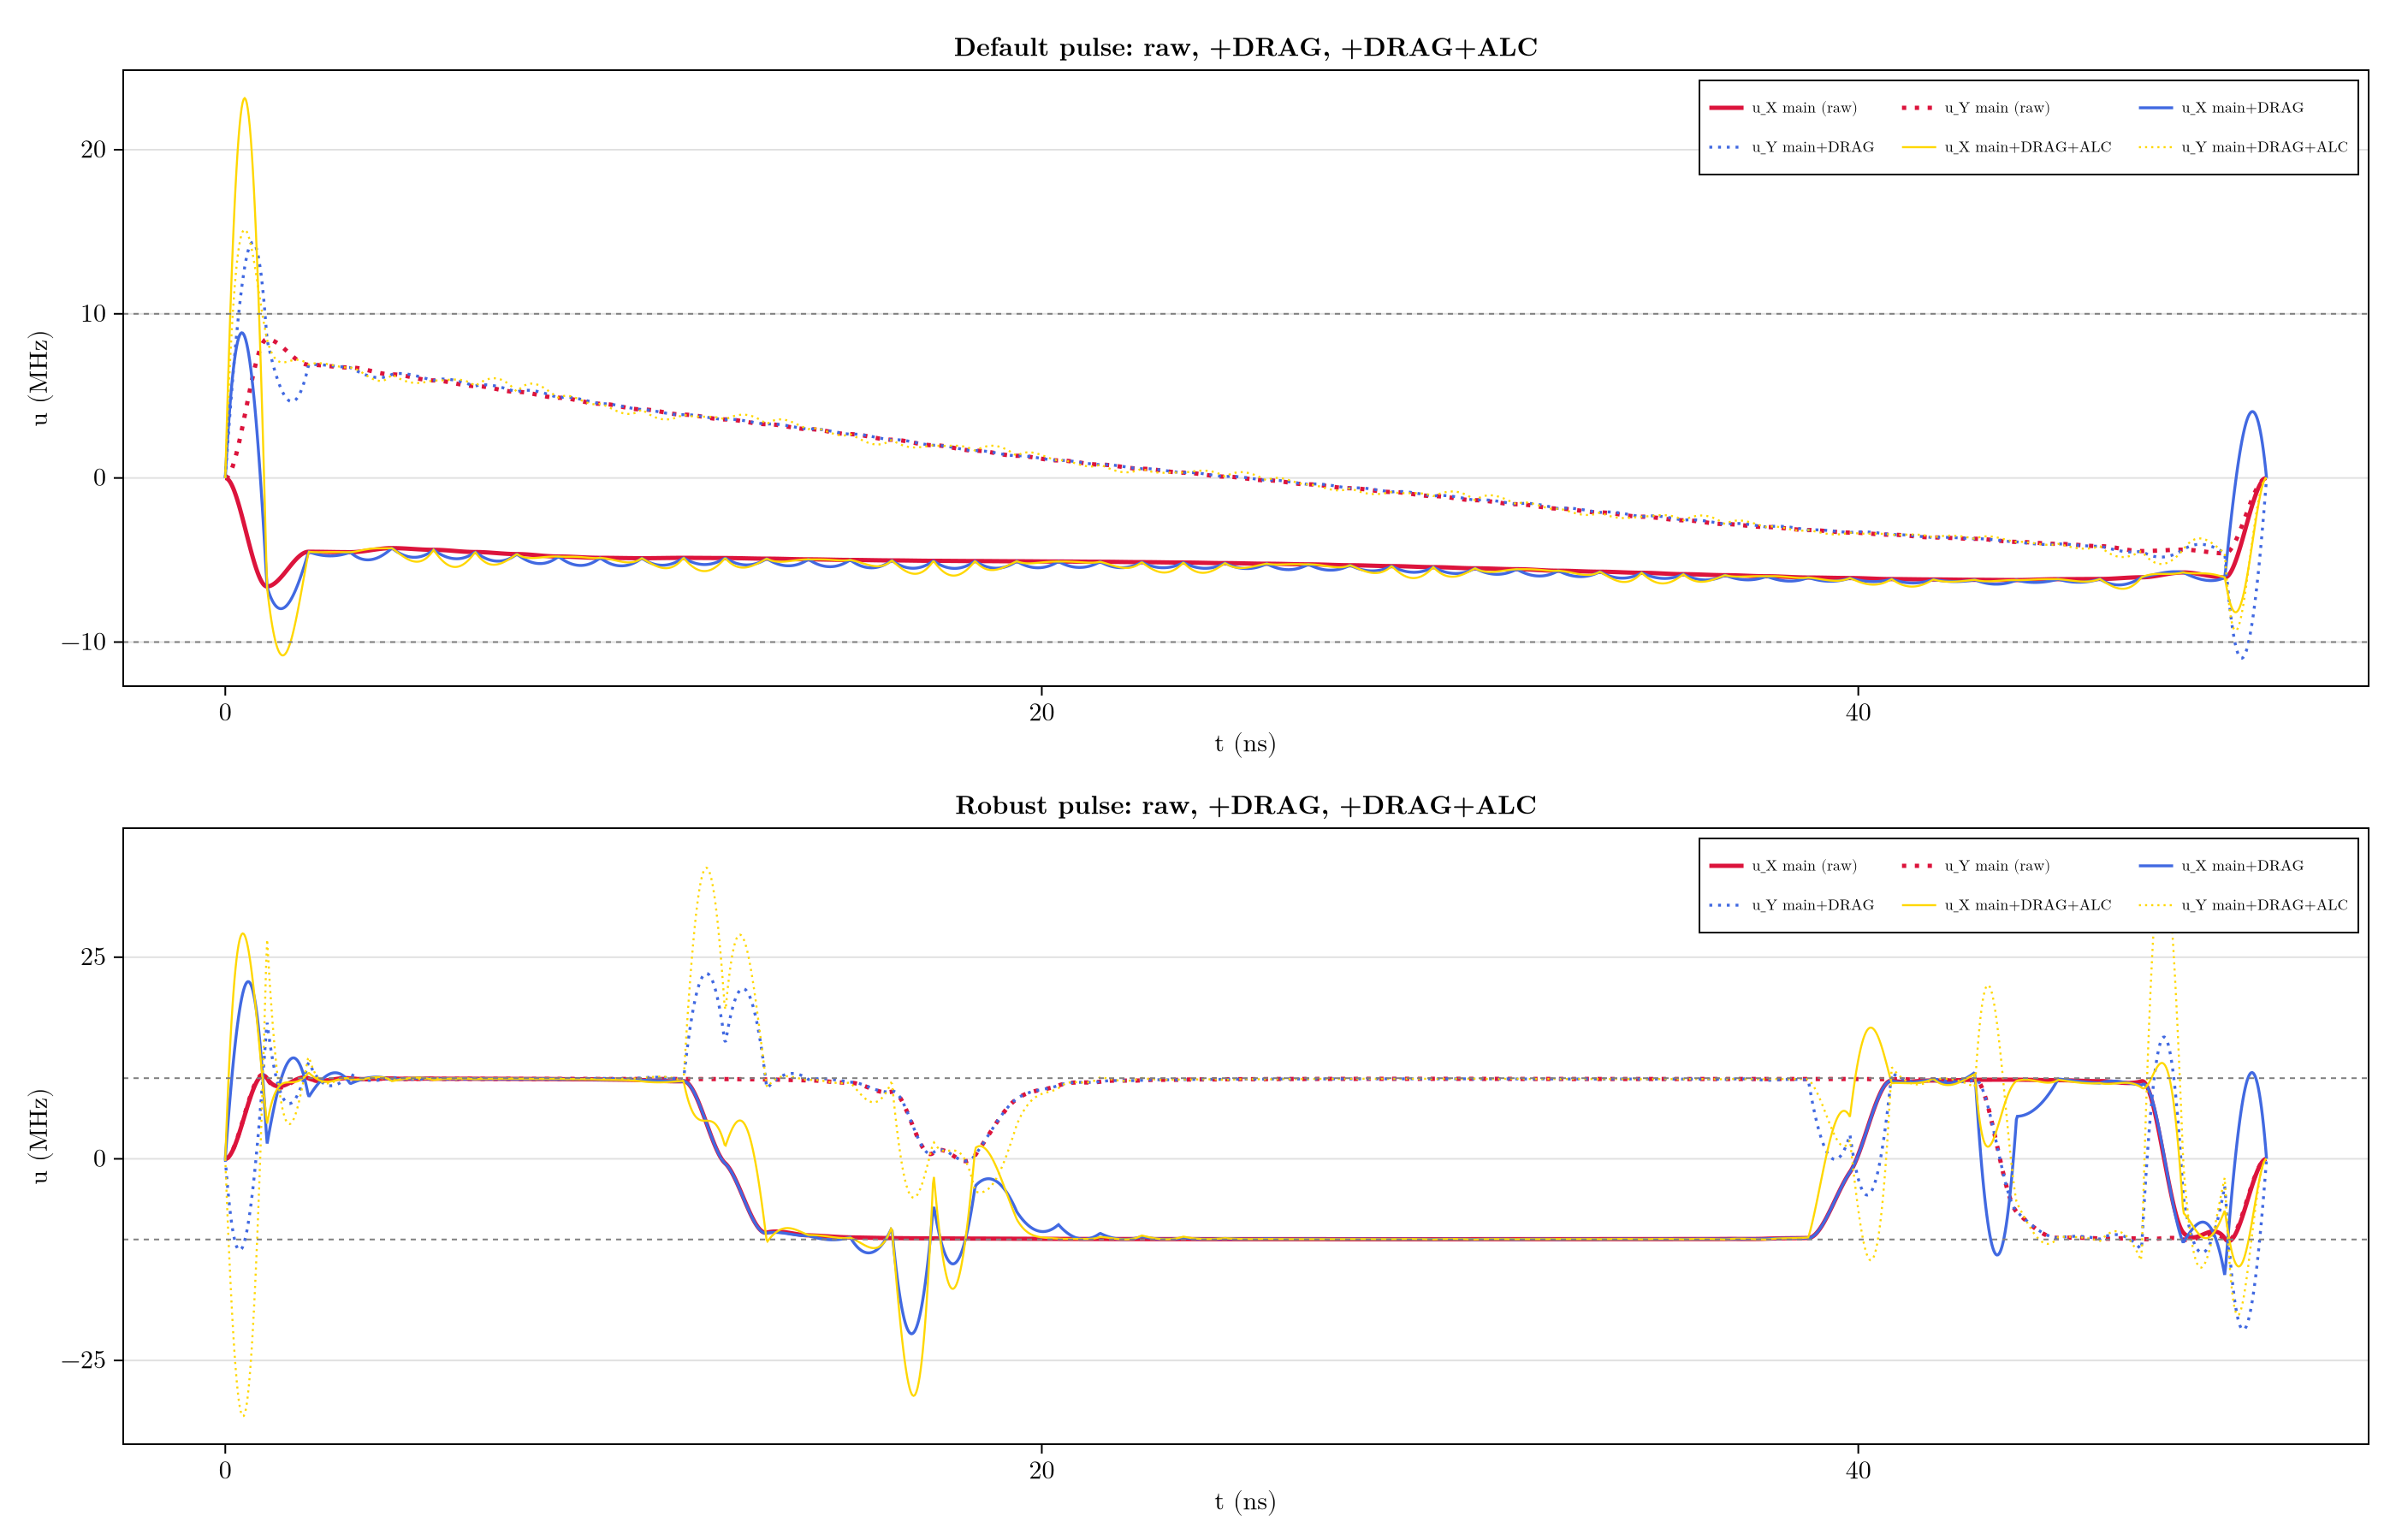

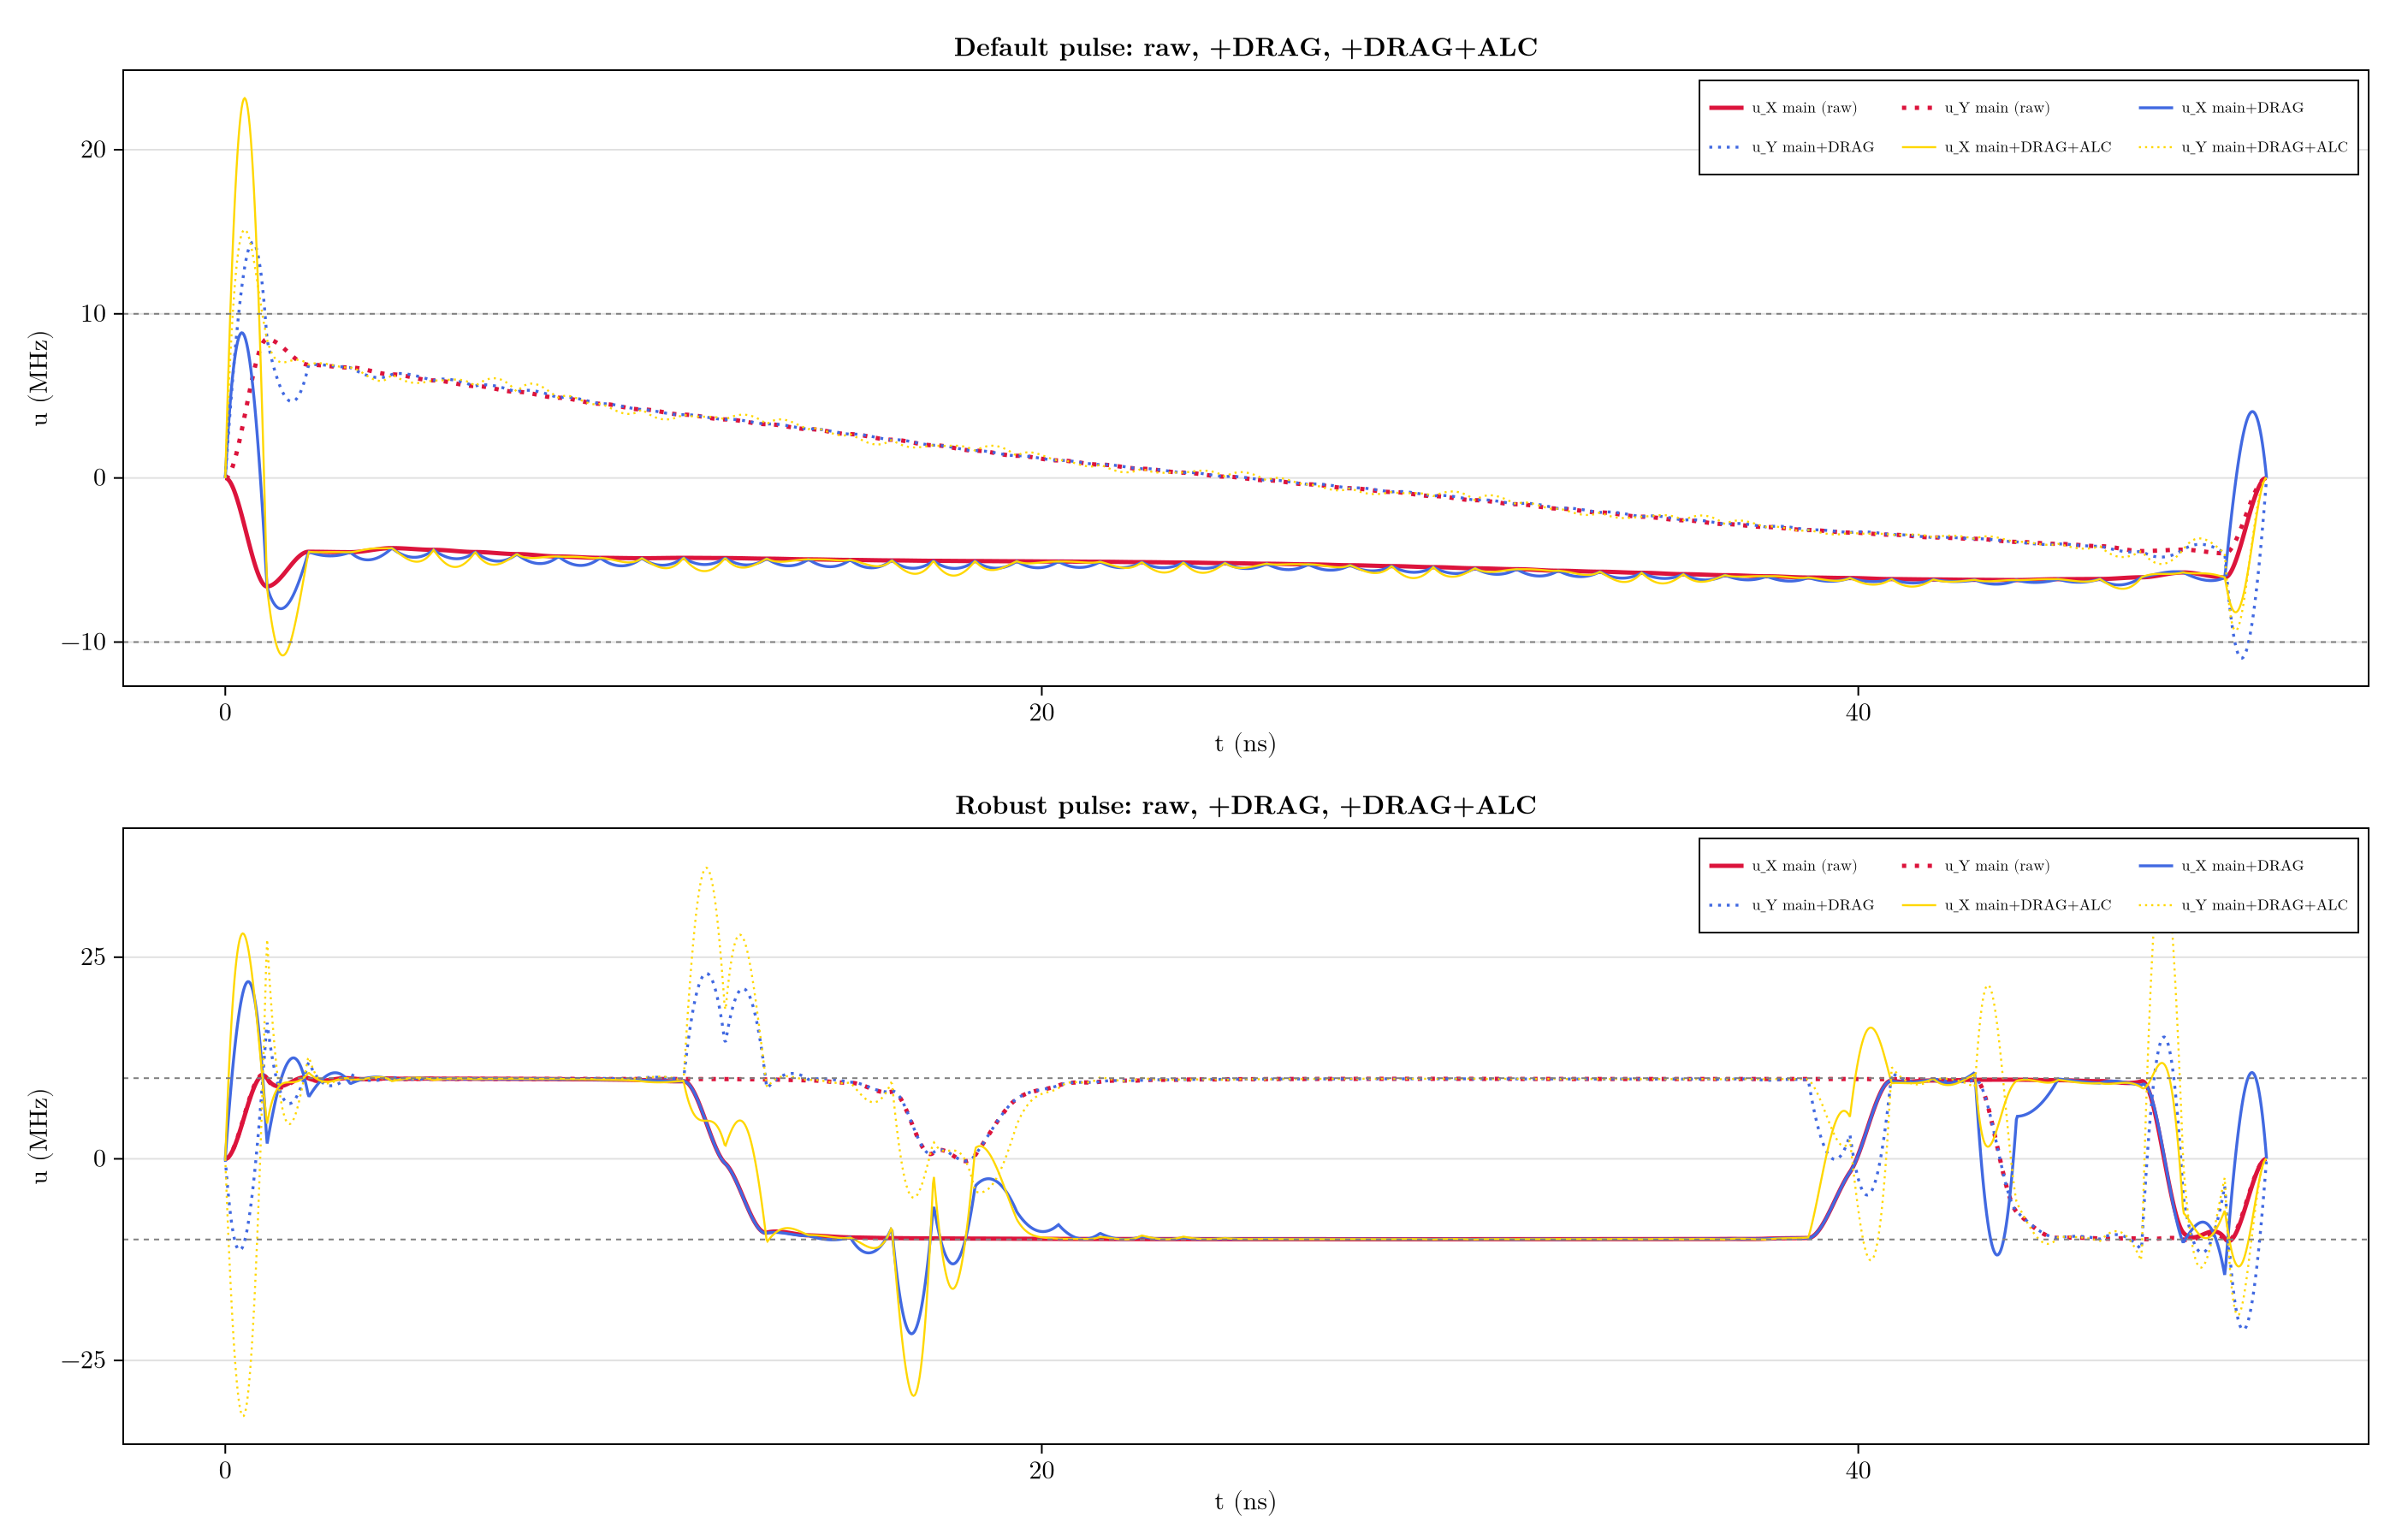

In [14]:
# Fig 1a style: raw vs +DRAG vs +DRAG+ALC, for default and robust
fig = Figure(size = (1400, 900), fontsize = 15)

function plot_pulse_panel!(ax, ts, uX1, uY1, uX_drag, uY_drag, uX_tot, uY_tot; title_str)
    ax.title = title_str
    lines!(ax, ts, uX1;      color = :crimson,    linewidth = 2.5, label = "u_X main (raw)")
    lines!(ax, ts, uY1;      color = :crimson,    linewidth = 2.5, linestyle = :dot,  label = "u_Y main (raw)")
    lines!(ax, ts, uX_drag;  color = :royalblue,  linewidth = 1.7, label = "u_X main+DRAG")
    lines!(ax, ts, uY_drag;  color = :royalblue,  linewidth = 1.7, linestyle = :dot,  label = "u_Y main+DRAG")
    lines!(ax, ts, uX_tot;   color = :gold,       linewidth = 1.2, label = "u_X main+DRAG+ALC")
    lines!(ax, ts, uY_tot;   color = :gold,       linewidth = 1.2, linestyle = :dot,  label = "u_Y main+DRAG+ALC")
    hlines!(ax, [a_bound, -a_bound] .* MHz_per_radperns;
        color = :gray, linestyle = :dash, linewidth = 1)
    axislegend(ax; position = :rt, labelsize = 9, nbanks = 3)
end

ax_d = Axis(fig[1, 1], xlabel = "t (ns)", ylabel = "u (MHz)")
plot_pulse_panel!(ax_d, ts_fine, uX1_d, uY1_d, uX_drag_d, uY_drag_d, uX_tot_d, uY_tot_d;
    title_str = "Default pulse: raw, +DRAG, +DRAG+ALC")

ax_r = Axis(fig[2, 1], xlabel = "t (ns)", ylabel = "u (MHz)")
plot_pulse_panel!(ax_r, ts_fine, uX1_r, uY1_r, uX_drag_r, uY_drag_r, uX_tot_r, uY_tot_r;
    title_str = "Robust pulse: raw, +DRAG, +DRAG+ALC")

display(fig); fig

## Section 6 — ε-sweep in 3-level Duffing with V = $\hat n$

Compares four cases: {default, robust} × {without ALC, with ALC}.

- **Without ALC** = main pulse only, propagated in 3-lvl Duffing (so leakage is unsuppressed)
- **With ALC** = composite (main + ALC at δ = η) propagated in 3-lvl Duffing

In [11]:
# Fine-grained midpoint-rule propagation in 3-lvl.
# `with_corr = true` → use main + DRAG + ALC (full Chiaro-Zhang waveform).
# `with_corr = false` → use raw main only.
function propagate_3lvl(pieces_fn, ε; N_fine = 1000, with_corr::Bool)
    ts_f = collect(range(0.0, T_NS, length = N_fine))
    dt_sub = ts_f[2] - ts_f[1]
    U = Matrix{ComplexF64}(I, 3, 3)
    for k in 1:N_fine - 1
        t_mid = 0.5 * (ts_f[k] + ts_f[k+1])
        uX1, uY1, _, _, uX_tot, uY_tot = pieces_fn(t_mid)
        uX = with_corr ? uX_tot : uX1
        uY = with_corr ? uY_tot : uY1
        H = H_anh3 + uX * X3 + uY * Y3 + ε * n3
        U = exp(-im * dt_sub * H) * U
    end
    return U
end

function eps_sweep_3lvl(pieces_fn; with_corr::Bool)
    Fs = Float64[]
    Ls = Float64[]
    for ε in εs
        U_T  = propagate_3lvl(pieces_fn, ε; with_corr = with_corr)
        Usub = U_T[subspace_indices, subspace_indices]
        push!(Fs, abs2(tr(U_target' * Usub)) / 4)
        push!(Ls, 1 - real(tr(Usub' * Usub)) / 2)
    end
    return Fs, Ls
end

# ---- Section 5.5: per-pulse calibration of (A_alc, δ_alc) ----
# Chiaro-Zhang's optimal (A_alc, δ_alc) assume F(t) is a symmetric raised cosine.
# For our optimizer-chosen Ω(t) those defaults give CONSTRUCTIVE interference
# instead of destructive at t=T → more leakage, not less.
# Fix: minimize 3-lvl leakage at ε=0 over a 2-D grid in (A_alc, δ_alc),
# separately for each pulse.  ~15×15 grid × 1000 substeps ≈ 25 s per pulse.
function calibrate_alc(traj;
        A_grid = collect(range(-1.5, 1.5, length = 15)),
        δ_grid = collect(range(0.5, 1.5, length = 15)) .* η_anh)
    L_min = Inf
    A_best, δ_best = 0.0, η_anh
    L_grid = zeros(length(A_grid), length(δ_grid))
    for (i, A) in enumerate(A_grid), (j, δ) in enumerate(δ_grid)
        pieces = build_composite(traj; A_alc = A, δ_alc = δ)
        U_T  = propagate_3lvl(pieces, 0.0; with_corr = true)
        Usub = U_T[subspace_indices, subspace_indices]
        L = 1 - real(tr(Usub' * Usub)) / 2
        L_grid[i, j] = L
        if L < L_min
            L_min = L; A_best = A; δ_best = δ
        end
    end
    return A_best, δ_best, L_min, A_grid, δ_grid, L_grid
end

println("Calibrating ALC for default pulse...")
@time A_d, δ_d, L_d_min, A_gd, δ_gd, Lg_d = calibrate_alc(traj_default)
@printf("  optimal (A_alc, δ_alc/2π[MHz]) = (%+.3f, %+.1f),  leakage = %.3e\n",
    A_d, δ_d/(2π)*1e3, L_d_min)

println("Calibrating ALC for robust pulse...")
@time A_r, δ_r, L_r_min, A_gr, δ_gr, Lg_r = calibrate_alc(traj_robust)
@printf("  optimal (A_alc, δ_alc/2π[MHz]) = (%+.3f, %+.1f),  leakage = %.3e\n",
    A_r, δ_r/(2π)*1e3, L_r_min)

# Build calibrated composite waveforms
comp_default_cal = build_composite(traj_default; A_alc = A_d, δ_alc = δ_d)
comp_robust_cal  = build_composite(traj_robust;  A_alc = A_r, δ_alc = δ_r)

println("\nRunning final 3-lvl ε-sweep with calibrated ALC...")
println("  default raw...")
@time F_def_raw, L_def_raw = eps_sweep_3lvl(comp_default;     with_corr = false)
println("  default + calibrated DRAG+ALC...")
@time F_def_cor, L_def_cor = eps_sweep_3lvl(comp_default_cal; with_corr = true)
println("  robust raw...")
@time F_rob_raw, L_rob_raw = eps_sweep_3lvl(comp_robust;      with_corr = false)
println("  robust + calibrated DRAG+ALC...")
@time F_rob_cor, L_rob_cor = eps_sweep_3lvl(comp_robust_cal;  with_corr = true)

mid = (length(εs) + 1) ÷ 2
@printf("\nAt ε=0:\n")
@printf("  default raw                    : F=%.6f, L=%.3e\n", F_def_raw[mid], L_def_raw[mid])
@printf("  default + calibrated DRAG+ALC  : F=%.6f, L=%.3e\n", F_def_cor[mid], L_def_cor[mid])
@printf("  robust  raw                    : F=%.6f, L=%.3e\n", F_rob_raw[mid], L_rob_raw[mid])
@printf("  robust  + calibrated DRAG+ALC  : F=%.6f, L=%.3e\n", F_rob_cor[mid], L_rob_cor[mid])


Propagating 3-lvl ε-sweep — default raw...
  1.165153 seconds (6.22 M allocations: 385.812 MiB, 4.86% gc time, 92.30% compilation time)
Propagating 3-lvl ε-sweep — default + DRAG + ALC...
  0.457508 seconds (1.53 M allocations: 146.605 MiB, 84.86% gc time)
Propagating 3-lvl ε-sweep — robust raw...
  0.072139 seconds (1.53 M allocations: 146.605 MiB)
Propagating 3-lvl ε-sweep — robust + DRAG + ALC...
  0.088004 seconds (1.53 M allocations: 146.605 MiB, 20.42% gc time)

At ε=0:
  default raw                : F=0.991522, L=7.163e-03
  default + DRAG + ALC       : F=0.942592, L=3.887e-02
  robust  raw                : F=0.946587, L=5.061e-02
  robust  + DRAG + ALC       : F=0.582005, L=2.739e-01


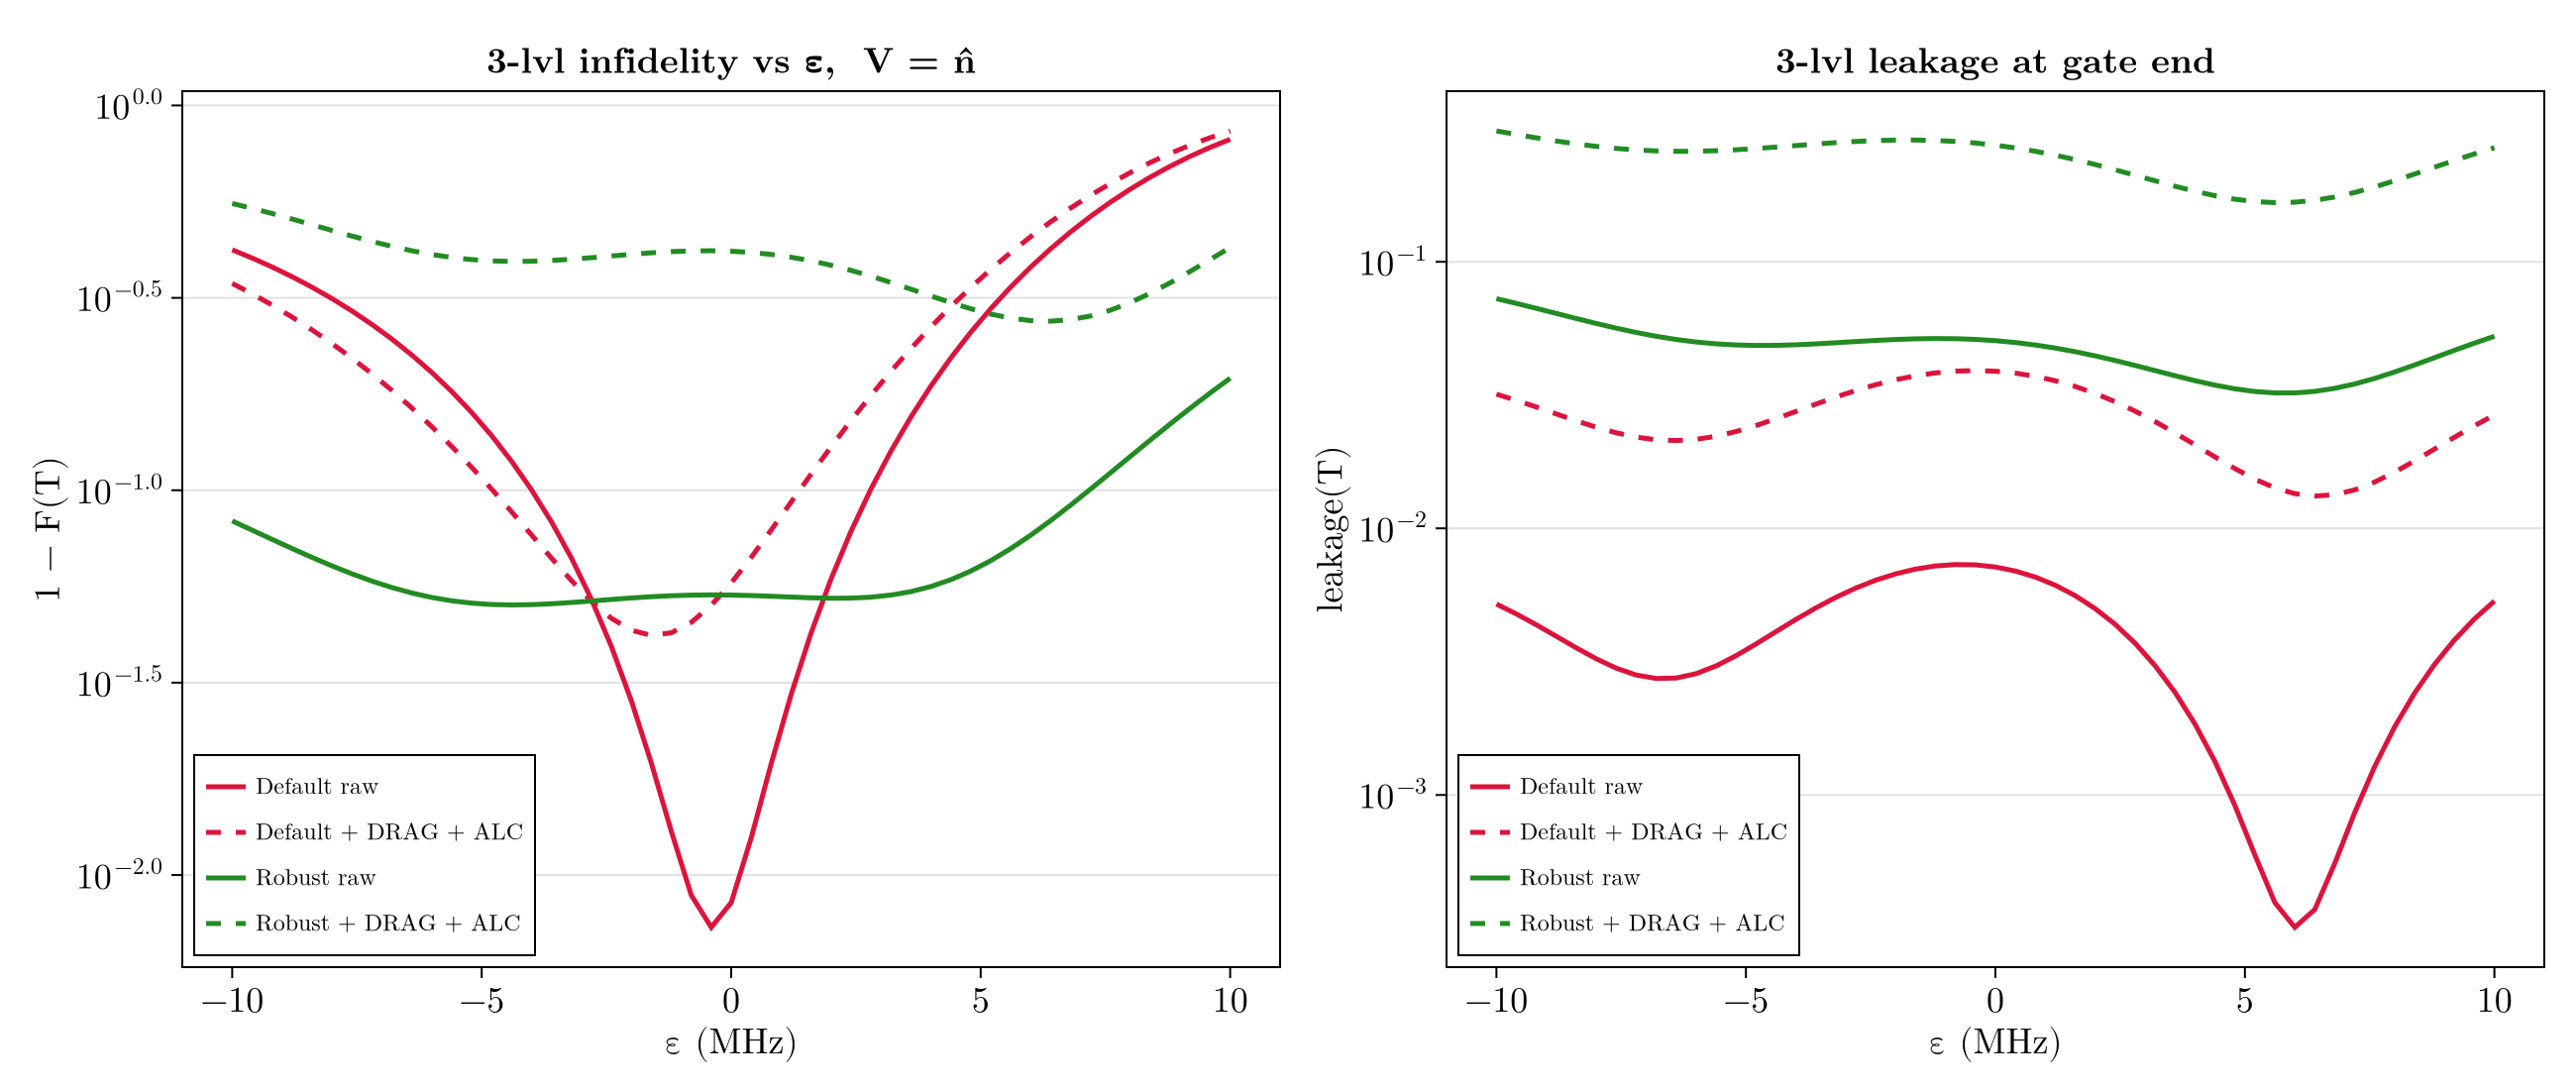

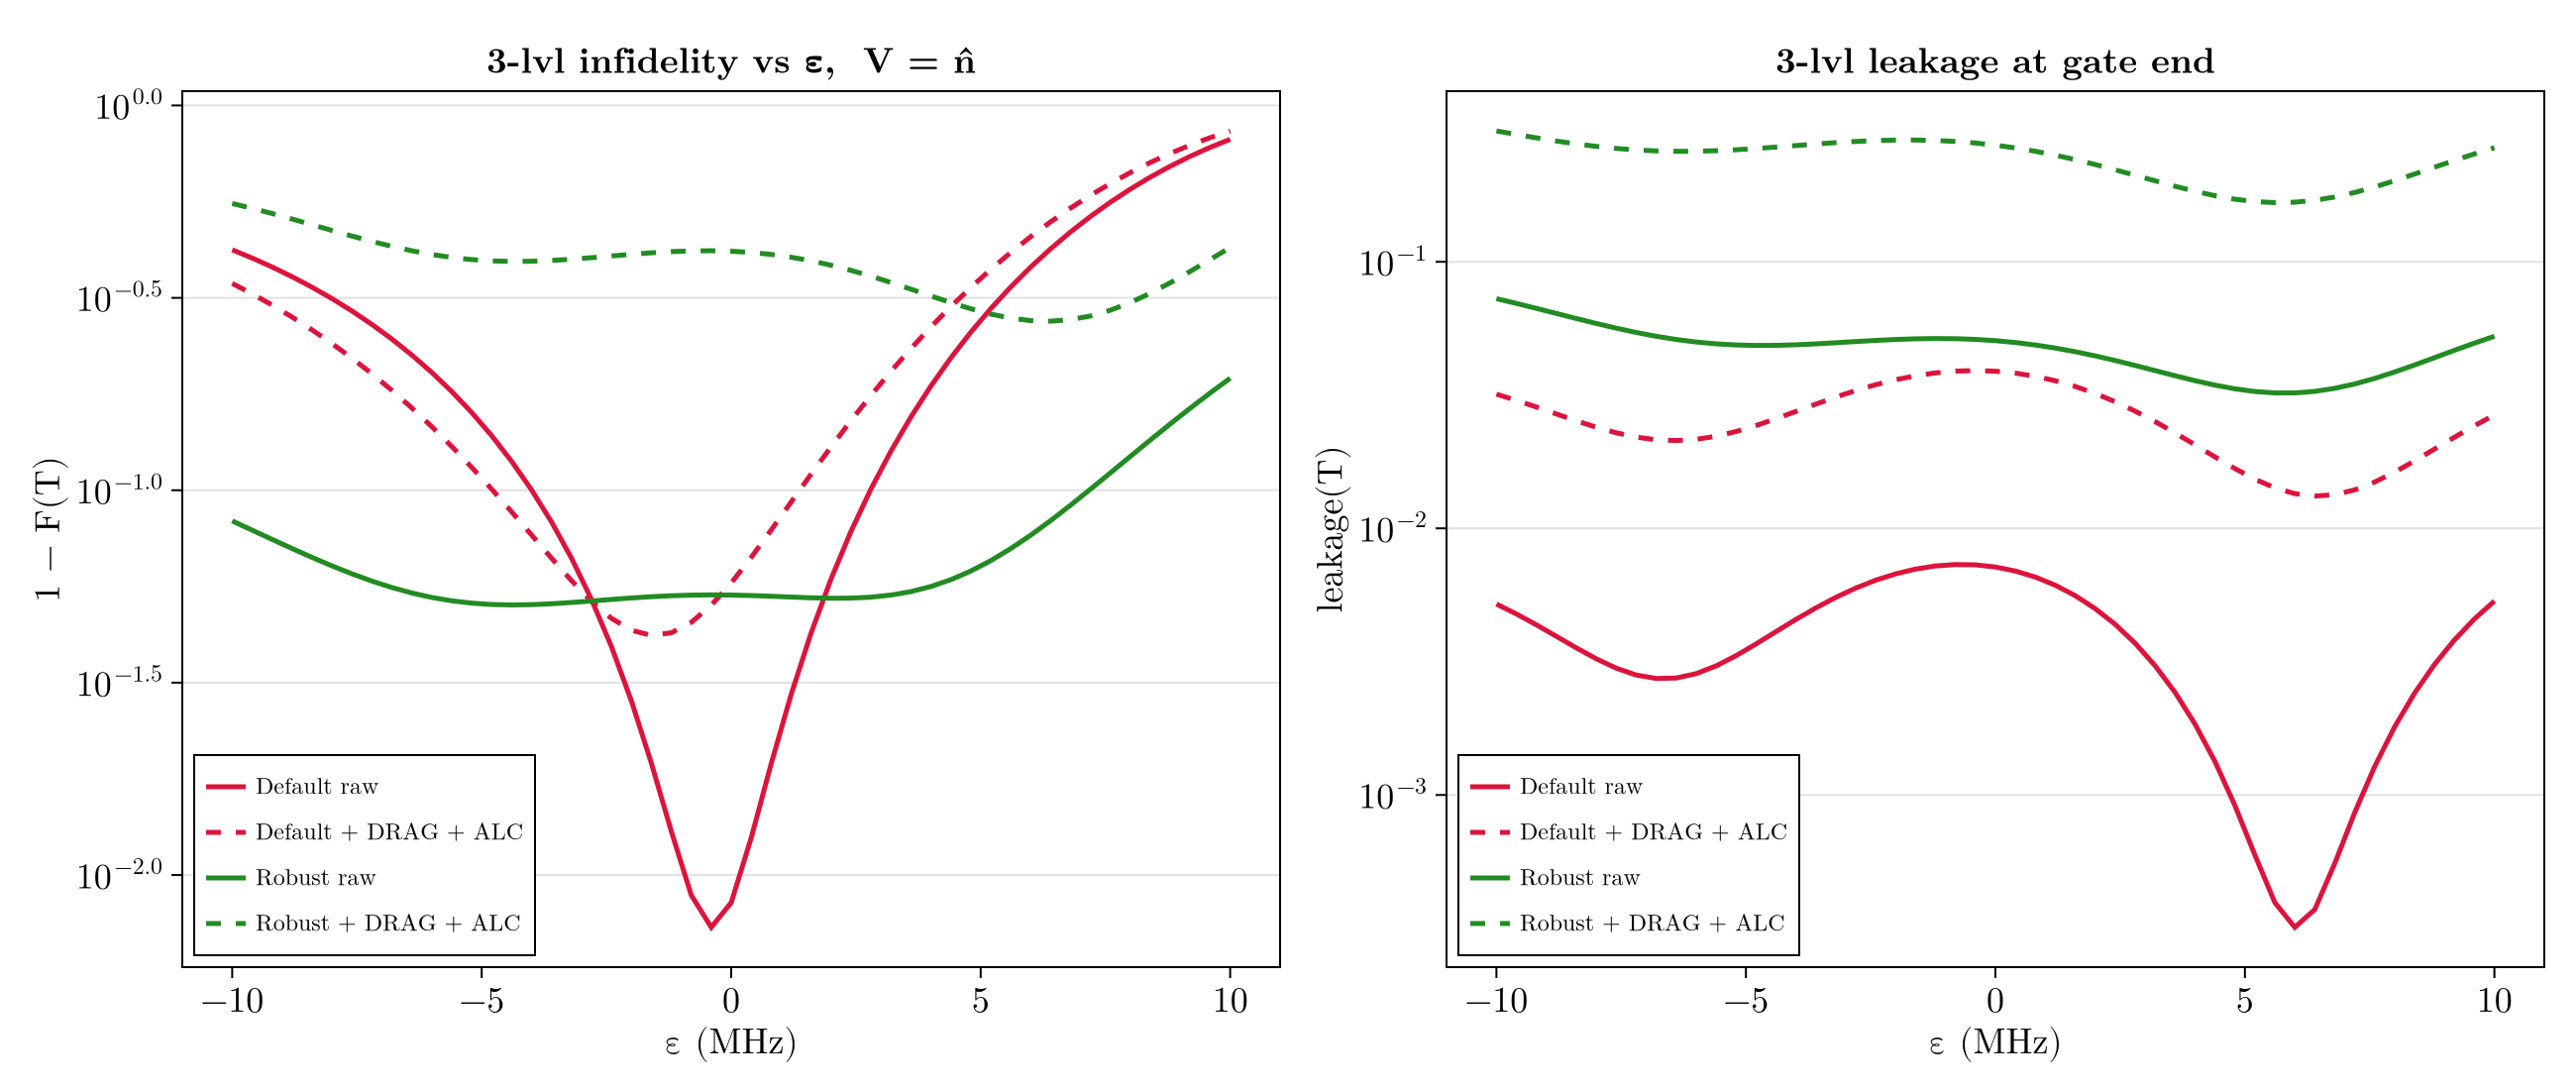

In [12]:
# Final plot: fidelity & leakage vs ε in 3-lvl, 4 curves (calibrated)
fig = Figure(size = (1300, 550), fontsize = 18)

ax_F = Axis(fig[1, 1], xlabel = "ε (MHz)", ylabel = "1 − F(T)",
    yscale = log10, title = "3-lvl infidelity vs ε,  V = n̂  (ALC calibrated)")
ax_L = Axis(fig[1, 2], xlabel = "ε (MHz)", ylabel = "leakage(T)",
    yscale = log10, title = "3-lvl leakage at gate end")

for (lbl, F, L, c, ls) in [
        ("Default raw",                    F_def_raw, L_def_raw, :crimson,     :solid),
        ("Default + calibrated DRAG+ALC",  F_def_cor, L_def_cor, :crimson,     :dash),
        ("Robust raw",                     F_rob_raw, L_rob_raw, :forestgreen, :solid),
        ("Robust + calibrated DRAG+ALC",   F_rob_cor, L_rob_cor, :forestgreen, :dash),
    ]
    lines!(ax_F, εs_MHz, max.(1 .- F, 1e-12);
        color = c, linewidth = 2.5, linestyle = ls, label = lbl)
    lines!(ax_L, εs_MHz, max.(L, 1e-12);
        color = c, linewidth = 2.5, linestyle = ls, label = lbl)
end

axislegend(ax_F; position = :lb, labelsize = 11)
axislegend(ax_L; position = :lb, labelsize = 11)
display(fig)
save(joinpath(@__DIR__, "alc_drag_3lvl_comparison_calibrated.png"), fig; px_per_unit = 4)
fig


In [ ]:
# ---- Calibration landscape: leakage(A_alc, δ_alc) at ε=0 for each pulse ----
fig = Figure(size = (1200, 500), fontsize = 16)

for (k, (Lg, A_g, δ_g, A_opt, δ_opt, title_str)) in enumerate([
        (Lg_d, A_gd, δ_gd, A_d, δ_d, "Default — leakage(A_alc, δ_alc) at ε=0"),
        (Lg_r, A_gr, δ_gr, A_r, δ_r, "Robust — leakage(A_alc, δ_alc) at ε=0"),
    ])
    ax = Axis(fig[1, k]; xlabel = "A_alc", ylabel = "δ_alc/2π (MHz)",
        title = title_str)
    hm = heatmap!(ax, A_g, δ_g ./ (2π) .* 1e3, log10.(max.(Lg, 1e-12));
        colormap = :viridis)
    scatter!(ax, [A_opt], [δ_opt / (2π) * 1e3]; color = :red, markersize = 18, marker = :star5)
    Colorbar(fig[1, k+2], hm; label = "log₁₀ leakage")
end

display(fig); fig
